In [63]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pprint



Band tags:  {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '0.57025331258774', 'STATISTICS_MEAN': '0.19133953605605', 'STATISTICS_MINIMUM': '0.0048654885031283', 'STATISTICS_STDDEV': '0.061290094116149', 'STATISTICS_VALID_PERCENT': '26.42'}


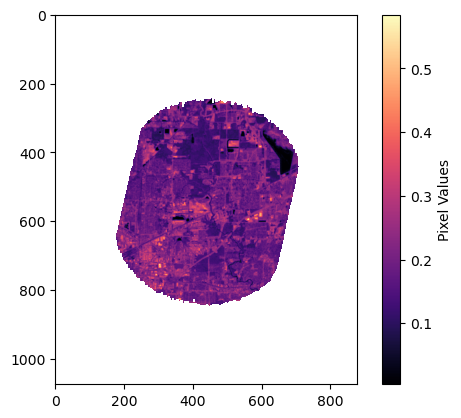

Band tags:  {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '1018.3204345703', 'STATISTICS_MEAN': '-11.724188796524', 'STATISTICS_MINIMUM': '-2114.5651855469', 'STATISTICS_STDDEV': '104.83265969991', 'STATISTICS_VALID_PERCENT': '26.42'}


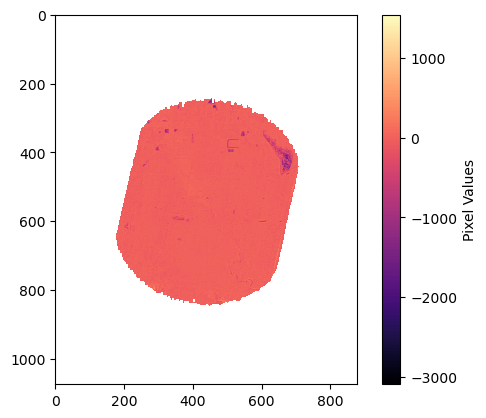

Band tags:  {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '1345.4851074219', 'STATISTICS_MEAN': '61.309647884806', 'STATISTICS_MINIMUM': '20.049583435059', 'STATISTICS_STDDEV': '69.327394287337', 'STATISTICS_VALID_PERCENT': '26.42'}


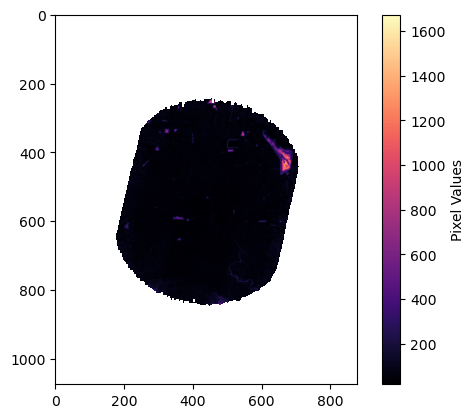

Band tags:  {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '3', 'STATISTICS_MEAN': '1.8347129506008', 'STATISTICS_MINIMUM': '1', 'STATISTICS_STDDEV': '0.50341618453553', 'STATISTICS_VALID_PERCENT': '98.74'}


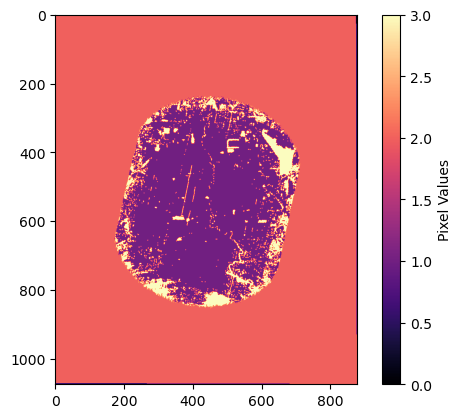

In [ ]:
# read multiple tiff files 

files = ["./ghgsat2803/2022/11/28/C5/C5_23010168_20221128_20230531_LbOSaFE/C5_23010168_20221128_20230531_LbOSaFE_ALB.tif", 
         "./ghgsat2803/2022/11/28/C5/C5_23010168_20221128_20230531_LbOSaFE/C5_23010168_20221128_20230531_LbOSaFE_CH4.tif", 
         "./ghgsat2803/2022/11/28/C5/C5_23010168_20221128_20230531_LbOSaFE/C5_23010168_20221128_20230531_LbOSaFE_CH4ER.tif",
         "./ghgsat2803/2022/11/28/C5/C5_23010168_20221128_20230531_LbOSaFE/C5_23010168_20221128_20230531_LbOSaFE_FLG.tif"]

titles = ["ALB", "ch4", "ch4er", "flg"]

for path in files:
    src = rasterio.open(path)
    band = src.read(1)
    meta = src.profile
    print("Band tags: ", src.tags(1))
    #pprint.pprint(meta)
    print("===============================")

    plt.imshow(band, cmap='magma')
    plt.colorbar(label='Pixel Values')
    #plt.title('Methane Enhancement or Radiance')
    plt.show()
# extract metadata from each  

# visualize the bands with matplot

/var/folders/sj/rh2rfdw10059tf3j96bb12jh0000gn/T/ipykernel_19570/2425847354.py:11: RuntimeWarning: All-NaN slice encountered
  cax = ax.imshow(window, cmap='magma', vmin=np.nanmin(window), vmax=np.nanmax(window))


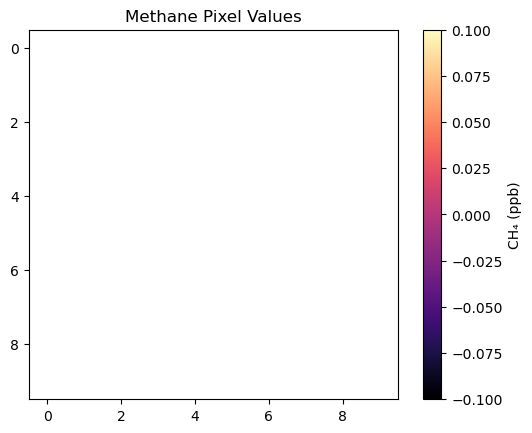

In [68]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("./ghgsat2803/2022/11/28/C5/C5_23010168_20221128_20230531_LbOSaFE/C5_23010168_20221128_20230531_LbOSaFE_CH4.tif") as src:
    ch4 = src.read(1)  # Band 1

# Slice out a small window
window = ch4[100:110, 200:210]

fig, ax = plt.subplots()
cax = ax.imshow(window, cmap='magma', vmin=np.nanmin(window), vmax=np.nanmax(window))
plt.colorbar(cax, label='CH₄ (ppb)')

for i in range(window.shape[0]):
    for j in range(window.shape[1]):
        val = window[i, j]
        ax.text(j, i, f"{val:.1f}", ha='center', va='center', color='white', fontsize=7)

plt.title("Methane Pixel Values")
plt.show()


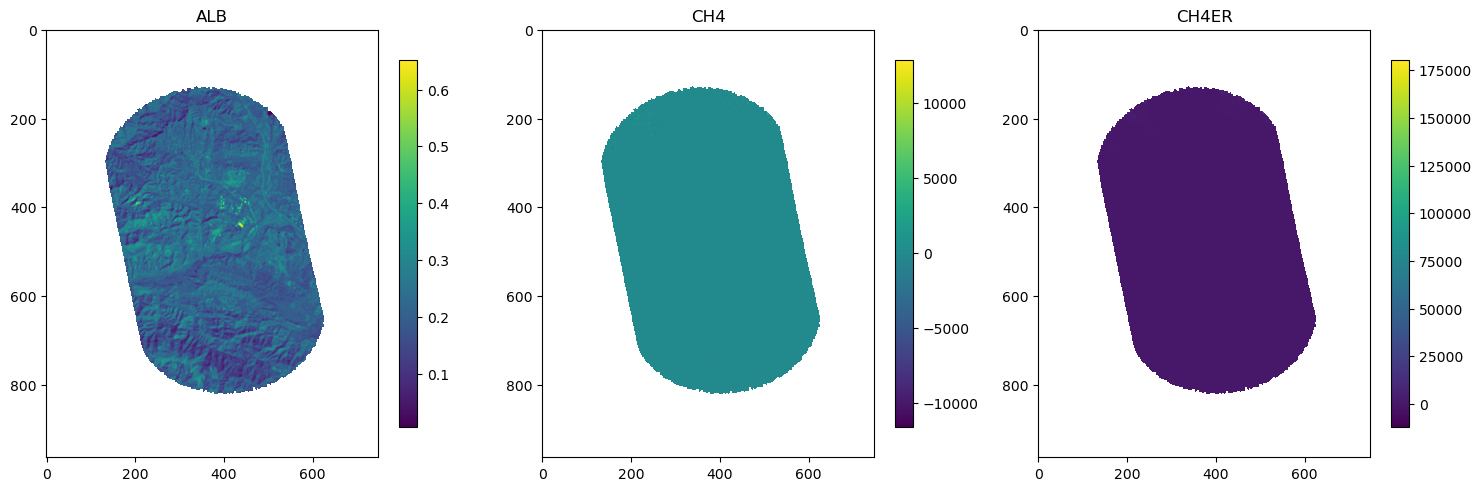

In [23]:
import rasterio
import numpy as np

files = ["./ghgsat2465/2024/03/08/C7/C7_24016881_20240308_20240311_SihBzsy/C7_24016881_20240308_20240311_SihBzsy_ALB.tif", 
         "./ghgsat2465/2024/03/08/C7/C7_24016881_20240308_20240311_SihBzsy/C7_24016881_20240308_20240311_SihBzsy_CH4.tif", 
         "./ghgsat2465/2024/03/08/C7/C7_24016881_20240308_20240311_SihBzsy/C7_24016881_20240308_20240311_SihBzsy_CH4ER.tif",
         "./ghgsat2465/2024/03/08/C7/C7_24016881_20240308_20240311_SihBzsy/C7_24016881_20240308_20240311_SihBzsy_FLG.tif"]
arrays = []
titles = ["ALB", "CH4", "CH4ER", "FLG"]

for f in files:
    with rasterio.open(f) as src:
        arrays.append(src.read(1))

stacked = np.stack(arrays, axis=0)  # Shape: (bands, rows, cols)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    im = axs[i].imshow(stacked[i], cmap='viridis')
    axs[i].set_title(titles[i])
    fig.colorbar(im, ax=axs[i], shrink=0.8)

plt.tight_layout()
plt.show()


In [40]:


#with rasterio.open("./ghgsat2465/2024/03/08/C7/C7_24016881_20240308_20240311_SihBzsy/C7_24016881_20240308_20240311_SihBzsy_ALB.tif") as src:
    #print("Driver:", src.driver)  # e.g., 'GTiff'
    #print("CRS:", src.crs)        # Coordinate Reference System
    #print("Transform:", src.transform)  # Affine mapping from pixel to coords
    #print("Width, Height:", src.width, src.height)
    #print("Bounds:", src.bounds)
    #print("Band count:", src.count)
   # print("Data type:", src.dtypes[0])  # e.g., 'float32'
  #  print("NoData value:", src.nodata)


print("==========================================================")




print("Full Metadata Dictionary:")
pprint.pprint(src.meta)







Full Metadata Dictionary:
{'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]'),
 'driver': 'GTiff',
 'dtype': 'float32',
 'height': 964,
 'nodata': nan,
 'transform': Affine(27.673683216936208, 0.0, 338065.1757946896,
       0.0, -27.673683216936208, 3823909.5879234513),
 'width': 748}
